# Comparativa de Modelos — PC vs Jetson Orin Nano
## Sistema de Navegación Asistida | Taller de Grado I
Compara automáticamente los resultados de PC (RTX 3070 Ti) y Jetson Orin Nano 8GB.
Incluye métricas de potencia (W) y temperatura (°C) para Jetson.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Directorios ───────────────────────────────────────────────────────────────
BASE = Path(r"F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation")
OUTPUT_PC     = BASE / "output"
OUTPUT_JETSON = BASE / "output_jetson"

# ── Modelos ───────────────────────────────────────────────────────────────────
MODELOS = {
    "yolo26n":      {"nombre": "YOLO26n",        "tipo": "Detector",    "color": "#2196F3"},
    "yolo26n_seg":  {"nombre": "YOLO26n-seg",    "tipo": "Detector",    "color": "#03A9F4"},
    "yolov8n":      {"nombre": "YOLOv8n",        "tipo": "Detector",    "color": "#00BCD4"},
    "bisenetv2":    {"nombre": "BiSeNetV2 (B2)", "tipo": "Segmentador", "color": "#FF9800"},
    "segformer_b0": {"nombre": "SegFormer-B0",   "tipo": "Segmentador", "color": "#FFC107"},
}

CRITERIO_LAT_MS = 300
CRITERIO_FPS    = 15

print(f"PC     : {OUTPUT_PC}")
print(f"Jetson : {OUTPUT_JETSON}")
print(f"Modelos: {list(MODELOS.keys())}")

PC     : F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation\output
Jetson : F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation\output_jetson
Modelos: ['yolo26n', 'yolo26n_seg', 'yolov8n', 'bisenetv2', 'segformer_b0']


In [11]:
# ── Leer CSVs ────────────────────────────────────────────────────────────────

def leer_resumen(carpeta: Path) -> dict:
    csvs = list(carpeta.glob("*_resumen.csv"))
    if not csvs:
        return None
    csv_path = sorted(csvs)[-1]
    print(f"  {carpeta.parent.name}/{carpeta.name}/{csv_path.name}")

    meta = {}; criterios = {}; data_lines = []
    with open(csv_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith("# Frames,"):
                meta["frames"] = int(line.split(",")[1])
            elif line.startswith("# gpu,"):
                meta["gpu"] = line.split(",")[1]
            elif line.startswith("# plataforma,"):
                meta["plataforma"] = line.split(",")[1]
            elif line.startswith("# Lat <300ms,"):
                criterios["lat"] = line.split(",")[1]
            elif line.startswith("# FPS >=15,"):
                criterios["fps"] = line.split(",")[1]
            elif line.startswith("# Estab <20%,"):
                criterios["estab"] = line.split(",")[1]
            elif not line.startswith("#") and line:
                data_lines.append(line)

    metricas = {}
    if len(data_lines) > 1:
        header = data_lines[0].split(",")
        for row in data_lines[1:]:
            vals = row.split(",")
            if len(vals) >= 3:
                nombre = vals[0]
                try:
                    metricas[nombre] = {
                        h: float(v) for h, v in zip(header[1:], vals[1:])
                        if v.strip()
                    }
                except ValueError:
                    pass

    return {"meta": meta, "criterios": criterios,
            "metricas": metricas, "csv": csv_path.name}


print("=== PC ===")
resultados_pc = {}
for k, info in MODELOS.items():
    carpeta = OUTPUT_PC / k
    if carpeta.exists():
        res = leer_resumen(carpeta)
        if res: resultados_pc[k] = res
    else:
        print(f"  [!] No encontrado: {k}")

print(f"\n=== JETSON ===")
resultados_jetson = {}
for k, info in MODELOS.items():
    carpeta = OUTPUT_JETSON / k
    if carpeta.exists():
        res = leer_resumen(carpeta)
        if res: resultados_jetson[k] = res
    else:
        print(f"  [!] No encontrado: {k}")

print(f"\nPC cargados    : {list(resultados_pc.keys())}")
print(f"Jetson cargados: {list(resultados_jetson.keys())}")

=== PC ===
  output/yolo26n/acera_test_resumen.csv
  output/yolo26n_seg/acera_test_resumen.csv
  output/yolov8n/acera_test_resumen.csv
  output/bisenetv2/acera_test_resumen.csv
  output/segformer_b0/acera_test_15fps_resumen.csv

=== JETSON ===
  output_jetson/yolo26n/acera_test_15fps_resumen.csv
  output_jetson/yolo26n_seg/acera_test_15fps_resumen.csv
  output_jetson/yolov8n/acera_test_15fps_resumen.csv
  output_jetson/bisenetv2/acera_test_15fps_resumen.csv
  output_jetson/segformer_b0/acera_test_15fps_resumen.csv

PC cargados    : ['yolo26n', 'yolo26n_seg', 'yolov8n', 'bisenetv2', 'segformer_b0']
Jetson cargados: ['yolo26n', 'yolo26n_seg', 'yolov8n', 'bisenetv2', 'segformer_b0']


In [12]:
# ── Construir DataFrames ──────────────────────────────────────────────────────

def construir_df(resultados, plataforma):
    filas = []
    for key, info in MODELOS.items():
        if key not in resultados: continue
        res = resultados[key]
        m   = res["metricas"]
        cr  = res["criterios"]

        def get(metrica, stat):
            return m.get(metrica, {}).get(stat, np.nan)

        fila = {
            "Modelo":          info["nombre"],
            "Plataforma":      plataforma,
            "Tipo":            info["tipo"],
            "Frames":          res["meta"].get("frames", "-"),
            "FPS media":       round(get("fps_instantaneo", "media"), 1),
            "FPS min":         round(get("fps_instantaneo", "min"),   1),
            "Lat media (ms)":  round(get("latencia_ms", "media"),     1),
            "Lat std (ms)":    round(get("latencia_ms", "std"),        1),
            "Lat p95 (ms)":    round(get("latencia_ms", "p95"),        1),
            "VRAM pico (MB)":  round(get("gpu_mb", "max"),             0),
            "Power medio (W)": round(get("power_w", "media"),          1),
            "Temp media (°C)": round(get("temp_c",  "media"),          1),
            "Sidewalk %":      round(get("pct_sidewalk", "media"),     1) if "pct_sidewalk" in m else "-",
            "✅ Lat":          cr.get("lat", "-"),
            "✅ FPS":          cr.get("fps", "-"),
            "✅ Estab":        cr.get("estab", "-"),
        }
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Modelo")


df_pc     = construir_df(resultados_pc,     "PC")
df_jetson = construir_df(resultados_jetson, "Jetson")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("\n=== PC (RTX 3070 Ti) ===")
print(df_pc[["Tipo","FPS media","Lat media (ms)","Lat p95 (ms)",
             "VRAM pico (MB)","Sidewalk %","✅ Lat","✅ FPS"]].to_string())

print("\n=== JETSON (Orin Nano 8GB) ===")
print(df_jetson[["Tipo","FPS media","Lat media (ms)","Lat p95 (ms)",
                 "VRAM pico (MB)","Power medio (W)","Temp media (°C)",
                 "Sidewalk %","✅ Lat","✅ FPS"]].to_string())


=== PC (RTX 3070 Ti) ===
                       Tipo  FPS media  Lat media (ms)  Lat p95 (ms)  VRAM pico (MB) Sidewalk %   ✅ Lat   ✅ FPS
Modelo                                                                                                         
YOLO26n            Detector       95.7            10.9          15.2          2642.0          -  CUMPLE  CUMPLE
YOLO26n-seg        Detector       73.3            14.6          22.6          2944.0          -  CUMPLE  CUMPLE
YOLOv8n            Detector       92.8            11.8          17.0          2605.0          -  CUMPLE  CUMPLE
BiSeNetV2 (B2)  Segmentador       57.9            20.4          33.9          2614.0        1.3  CUMPLE  CUMPLE
SegFormer-B0    Segmentador       68.5            15.9          21.2          2521.0        3.2  CUMPLE  CUMPLE

=== JETSON (Orin Nano 8GB) ===
                       Tipo  FPS media  Lat media (ms)  Lat p95 (ms)  VRAM pico (MB)  Power medio (W)  Temp media (°C) Sidewalk %   ✅ Lat      ✅ FPS
Modelo   

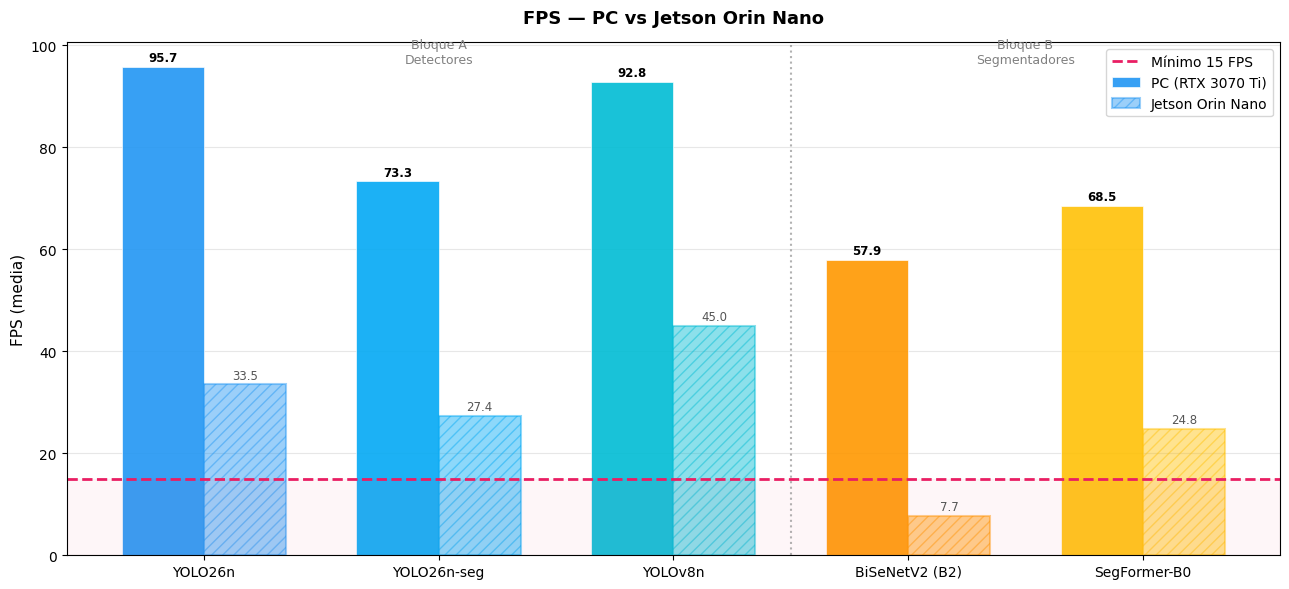

Guardada: comparativa_fps_pc_vs_jetson.png


In [13]:
# ── Gráfica 1: FPS PC vs Jetson ───────────────────────────────────────────────

modelos_comunes = [k for k in MODELOS if k in resultados_pc and k in resultados_jetson]
nombres = [MODELOS[k]["nombre"] for k in modelos_comunes]
colores = [MODELOS[k]["color"]  for k in modelos_comunes]
x = np.arange(len(nombres))
ancho = 0.35

fps_pc     = [resultados_pc[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
              for k in modelos_comunes]
fps_jetson = [resultados_jetson[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
              for k in modelos_comunes]

fig, ax = plt.subplots(figsize=(13, 6))

bars_pc     = ax.bar(x - ancho/2, fps_pc,     ancho, color=colores, alpha=0.90,
                     label="PC (RTX 3070 Ti)", edgecolor="white", lw=0.5)
bars_jetson = ax.bar(x + ancho/2, fps_jetson, ancho, color=colores, alpha=0.45,
                     label="Jetson Orin Nano", edgecolor=colores, lw=1.5,
                     hatch="///")

ax.axhline(CRITERIO_FPS, color="#E91E63", lw=2, ls="--",
           label=f"Mínimo {CRITERIO_FPS} FPS")
ax.axhspan(0, CRITERIO_FPS, alpha=0.04, color="#E91E63")

for bar, val in zip(bars_pc, fps_pc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for bar, val in zip(bars_jetson, fps_jetson):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8.5, color="#555")

# Separador Bloque A / Bloque B
n_det = sum(1 for k in modelos_comunes if MODELOS[k]["tipo"] == "Detector")
if 0 < n_det < len(nombres):
    ax.axvline(n_det - 0.5, color="gray", ls=":", lw=1.5, alpha=0.6)
    ax.text(n_det/2 - 0.5,       ax.get_ylim()[1]*0.96, "Bloque A\nDetectores",
            ha="center", fontsize=9, color="gray")
    ax.text(n_det+(len(nombres)-n_det)/2-0.5, ax.get_ylim()[1]*0.96,
            "Bloque B\nSegmentadores", ha="center", fontsize=9, color="gray")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("FPS (media)", fontsize=11)
ax.set_title("FPS — PC vs Jetson Orin Nano", fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_PC/"comparativa_fps_pc_vs_jetson.png", dpi=150)
plt.show()
print("Guardada: comparativa_fps_pc_vs_jetson.png")

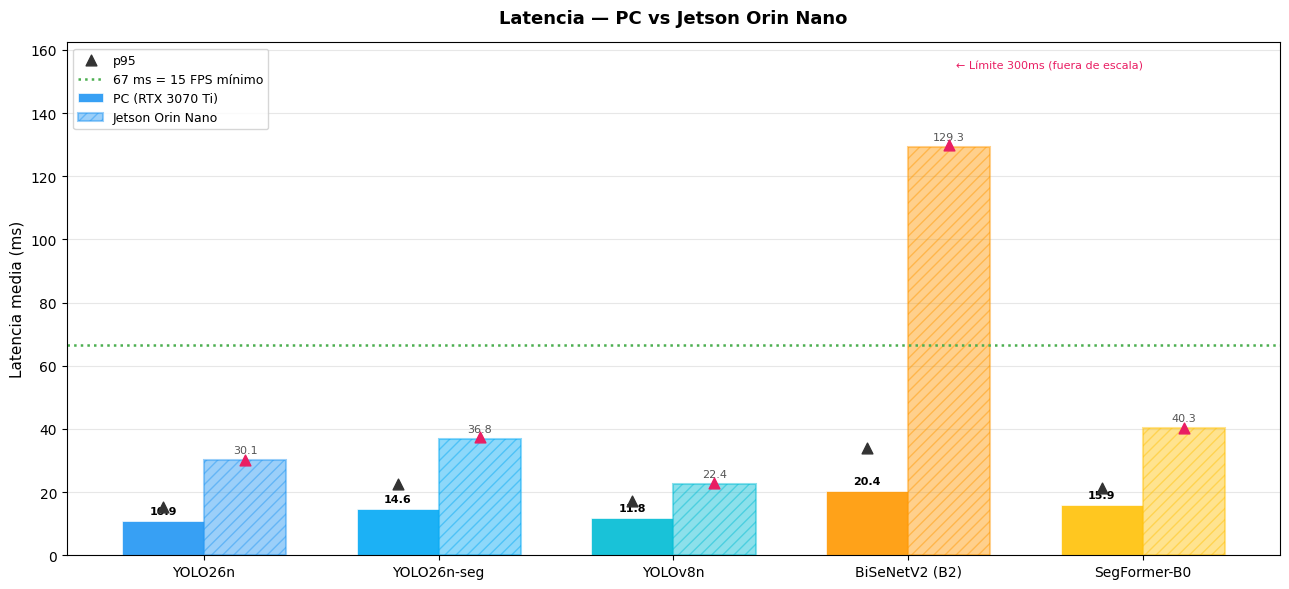

Guardada: comparativa_latencia_pc_vs_jetson.png


In [14]:
# ── Gráfica 2: Latencia PC vs Jetson ─────────────────────────────────────────

lat_pc     = [resultados_pc[k]["metricas"].get("latencia_ms",{}).get("media",0)
              for k in modelos_comunes]
lat_jetson = [resultados_jetson[k]["metricas"].get("latencia_ms",{}).get("media",0)
              for k in modelos_comunes]
p95_pc     = [resultados_pc[k]["metricas"].get("latencia_ms",{}).get("p95",0)
              for k in modelos_comunes]
p95_jetson = [resultados_jetson[k]["metricas"].get("latencia_ms",{}).get("p95",0)
              for k in modelos_comunes]

fig, ax = plt.subplots(figsize=(13, 6))

bars_pc     = ax.bar(x - ancho/2, lat_pc,     ancho, color=colores, alpha=0.90,
                     label="PC (RTX 3070 Ti)", edgecolor="white", lw=0.5)
bars_jetson = ax.bar(x + ancho/2, lat_jetson, ancho, color=colores, alpha=0.45,
                     label="Jetson Orin Nano", edgecolor=colores, lw=1.5,
                     hatch="///")

# p95 markers
ax.scatter(x - ancho/2, p95_pc,     marker="^", s=60, color="#333",    zorder=5, label="p95")
ax.scatter(x + ancho/2, p95_jetson, marker="^", s=60, color="#E91E63", zorder=5)

# Escala dinámica
y_max = max(max(p95_pc), max(p95_jetson)) * 1.25
ax.set_ylim(0, y_max)

lim_fps = 1000 / CRITERIO_FPS
ax.axhline(lim_fps, color="#4CAF50", lw=1.8, ls=":",
           label=f"{lim_fps:.0f} ms = {CRITERIO_FPS} FPS mínimo")

if CRITERIO_LAT_MS < y_max:
    ax.axhline(CRITERIO_LAT_MS, color="#E91E63", lw=1.8, ls="--",
               label=f"Límite {CRITERIO_LAT_MS} ms")
else:
    ax.annotate(f"← Límite {CRITERIO_LAT_MS}ms (fuera de escala)",
                xy=(len(nombres)-1, y_max*0.95), fontsize=8, color="#E91E63", ha="right")

for bar, val in zip(bars_pc, lat_pc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+y_max*0.01,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar, val in zip(bars_jetson, lat_jetson):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+y_max*0.01,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8, color="#555")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("Latencia media (ms)", fontsize=11)
ax.set_title("Latencia — PC vs Jetson Orin Nano", fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9, loc="upper left")
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_PC/"comparativa_latencia_pc_vs_jetson.png", dpi=150)
plt.show()
print("Guardada: comparativa_latencia_pc_vs_jetson.png")

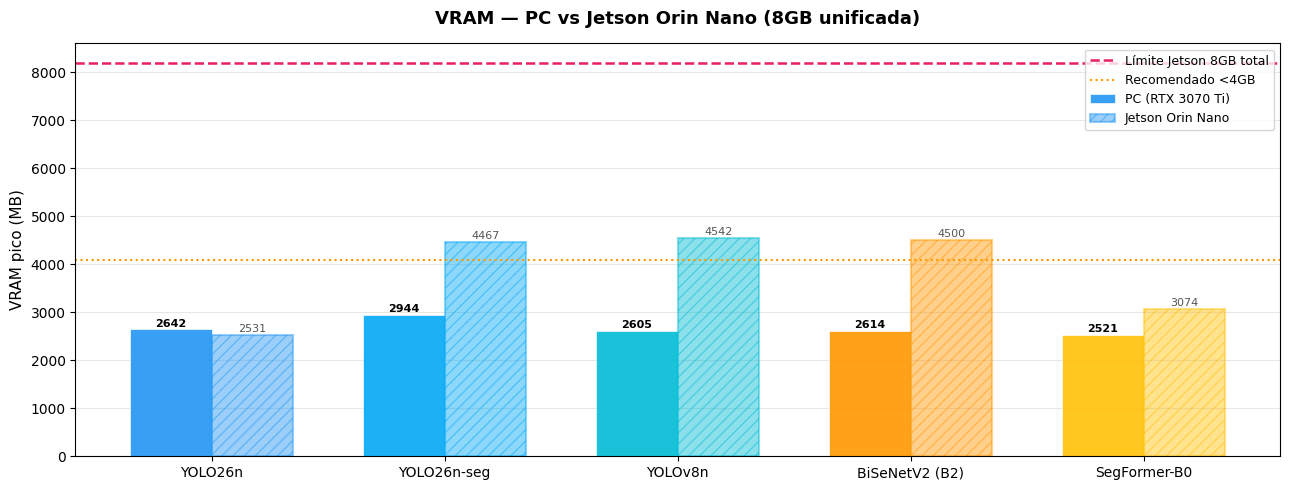

Guardada: comparativa_vram_pc_vs_jetson.png


In [15]:
# ── Gráfica 3: VRAM (referencia Jetson 8GB) ───────────────────────────────────

vram_pc     = [resultados_pc[k]["metricas"].get("gpu_mb",{}).get("max",0)
               for k in modelos_comunes]
vram_jetson = [resultados_jetson[k]["metricas"].get("gpu_mb",{}).get("max",0)
               for k in modelos_comunes]

fig, ax = plt.subplots(figsize=(13, 5))

bars_pc     = ax.bar(x - ancho/2, vram_pc,     ancho, color=colores, alpha=0.90,
                     label="PC (RTX 3070 Ti)", edgecolor="white", lw=0.5)
bars_jetson = ax.bar(x + ancho/2, vram_jetson, ancho, color=colores, alpha=0.45,
                     label="Jetson Orin Nano", edgecolor=colores, lw=1.5,
                     hatch="///")

ax.axhline(8192, color="#E91E63", lw=1.8, ls="--", label="Límite Jetson 8GB total")
ax.axhline(4096, color="#FF9800", lw=1.5, ls=":",  label="Recomendado <4GB")

for bar, val in zip(bars_pc, vram_pc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f"{val:.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar, val in zip(bars_jetson, vram_jetson):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f"{val:.0f}", ha="center", va="bottom", fontsize=8, color="#555")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("VRAM pico (MB)", fontsize=11)
ax.set_title("VRAM — PC vs Jetson Orin Nano (8GB unificada)",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_PC/"comparativa_vram_pc_vs_jetson.png", dpi=150)
plt.show()
print("Guardada: comparativa_vram_pc_vs_jetson.png")

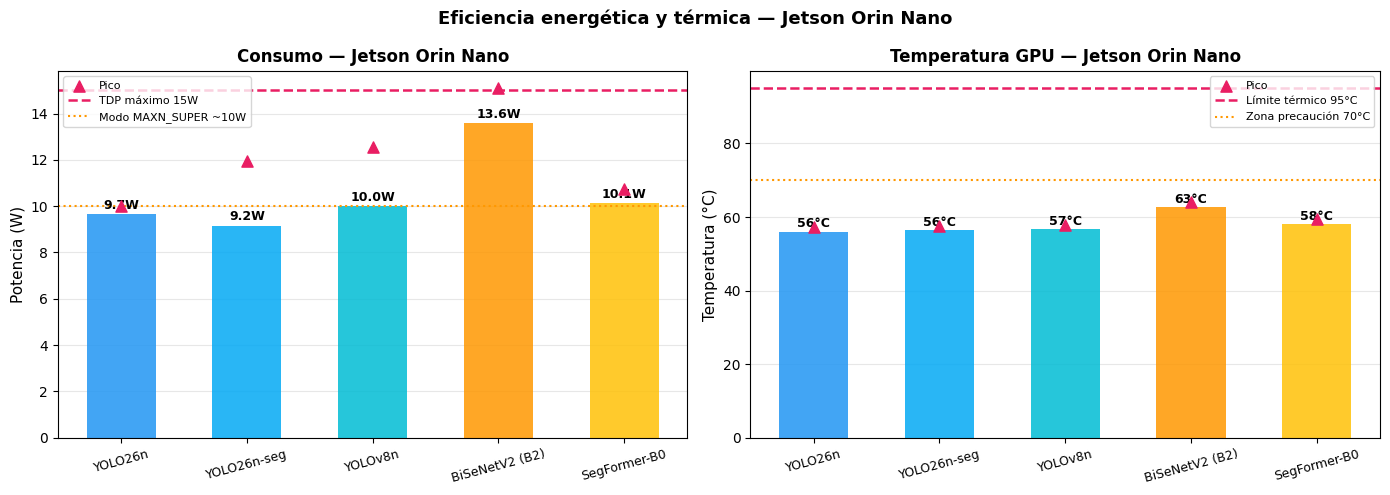

Guardada: comparativa_power_temp_jetson.png


In [16]:
# ── Gráfica 4: Potencia y Temperatura Jetson ──────────────────────────────────
# Solo Jetson tiene estas métricas

modelos_j = [k for k in MODELOS if k in resultados_jetson]
nombres_j = [MODELOS[k]["nombre"] for k in modelos_j]
colores_j = [MODELOS[k]["color"]  for k in modelos_j]
x_j = np.arange(len(nombres_j))

power_vals = [resultados_jetson[k]["metricas"].get("power_w",{}).get("media",0)
              for k in modelos_j]
power_max  = [resultados_jetson[k]["metricas"].get("power_w",{}).get("max",0)
              for k in modelos_j]
temp_vals  = [resultados_jetson[k]["metricas"].get("temp_c",{}).get("media",0)
              for k in modelos_j]
temp_max   = [resultados_jetson[k]["metricas"].get("temp_c",{}).get("max",0)
              for k in modelos_j]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Potencia
bars = ax1.bar(x_j, power_vals, 0.55, color=colores_j, alpha=0.85)
ax1.scatter(x_j, power_max, marker="^", s=65, color="#E91E63",
            zorder=5, label="Pico")
ax1.axhline(15, color="#E91E63", lw=1.8, ls="--", label="TDP máximo 15W")
ax1.axhline(10, color="#FF9800", lw=1.5, ls=":",  label="Modo MAXN_SUPER ~10W")
for bar, val in zip(bars, power_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val:.1f}W", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_xticks(x_j); ax1.set_xticklabels(nombres_j, fontsize=9, rotation=15)
ax1.set_ylabel("Potencia (W)", fontsize=11)
ax1.set_title("Consumo — Jetson Orin Nano", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8); ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

# Temperatura
bars2 = ax2.bar(x_j, temp_vals, 0.55, color=colores_j, alpha=0.85)
ax2.scatter(x_j, temp_max, marker="^", s=65, color="#E91E63",
            zorder=5, label="Pico")
ax2.axhline(95, color="#E91E63", lw=1.8, ls="--", label="Límite térmico 95°C")
ax2.axhline(70, color="#FF9800", lw=1.5, ls=":",  label="Zona precaución 70°C")
for bar, val in zip(bars2, temp_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.0f}°C", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_xticks(x_j); ax2.set_xticklabels(nombres_j, fontsize=9, rotation=15)
ax2.set_ylabel("Temperatura (°C)", fontsize=11)
ax2.set_title("Temperatura GPU — Jetson Orin Nano", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

plt.suptitle("Eficiencia energética y térmica — Jetson Orin Nano",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PC/"comparativa_power_temp_jetson.png", dpi=150)
plt.show()
print("Guardada: comparativa_power_temp_jetson.png")

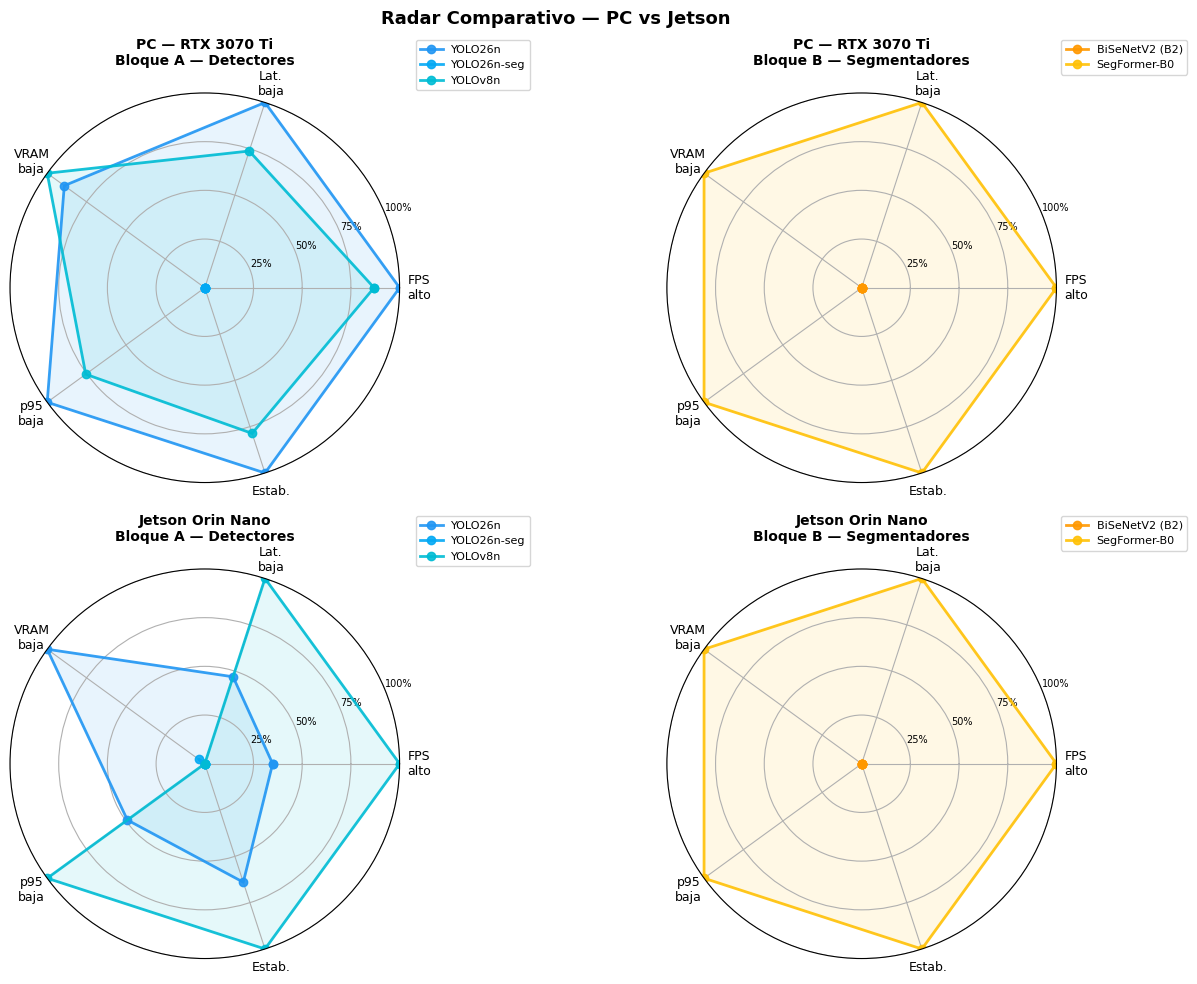

Guardada: comparativa_radar_pc_vs_jetson.png


In [17]:
# ── Gráfica 5: Radar PC vs Jetson ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw=dict(polar=True))

categorias = ["FPS\nalto", "Lat.\nbaja", "VRAM\nbaja", "p95\nbaja", "Estab."]
N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

def normalizar(arr, invert=False):
    arr = np.array(arr, dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn: return np.ones_like(arr) * 0.5
    n = (arr - mn) / (mx - mn)
    return 1 - n if invert else n

for row_idx, (res_dict, plat) in enumerate([
        (resultados_pc, "PC — RTX 3070 Ti"),
        (resultados_jetson, "Jetson Orin Nano")]):
    for col_idx, (tipo, titulo) in enumerate([
            ("Detector", "Bloque A — Detectores"),
            ("Segmentador", "Bloque B — Segmentadores")]):
        ax = axes[row_idx][col_idx]
        keys_tipo = [k for k in res_dict if MODELOS[k]["tipo"] == tipo]
        if not keys_tipo:
            ax.set_title(f"{plat}\n{titulo}\n(sin datos)"); continue

        fps_n  = normalizar([res_dict[k]["metricas"].get("fps_instantaneo",{}).get("media",0) for k in keys_tipo])
        lat_n  = normalizar([res_dict[k]["metricas"].get("latencia_ms",{}).get("media",0) for k in keys_tipo], invert=True)
        vram_n = normalizar([res_dict[k]["metricas"].get("gpu_mb",{}).get("max",0) for k in keys_tipo], invert=True)
        p95_n  = normalizar([res_dict[k]["metricas"].get("latencia_ms",{}).get("p95",0) for k in keys_tipo], invert=True)
        std_n  = normalizar([res_dict[k]["metricas"].get("latencia_ms",{}).get("std",0) for k in keys_tipo], invert=True)

        for i, k in enumerate(keys_tipo):
            vals = [fps_n[i], lat_n[i], vram_n[i], p95_n[i], std_n[i]]
            vals += vals[:1]
            color = MODELOS[k]["color"]
            ax.plot(angulos, vals, "o-", lw=2, color=color,
                    label=MODELOS[k]["nombre"], alpha=0.9)
            ax.fill(angulos, vals, alpha=0.10, color=color)

        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(categorias, fontsize=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=7)
        ax.set_title(f"{plat}\n{titulo}", fontsize=10, fontweight="bold", pad=20)
        ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)

fig.suptitle("Radar Comparativo — PC vs Jetson", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PC/"comparativa_radar_pc_vs_jetson.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: comparativa_radar_pc_vs_jetson.png")

In [23]:
# ── Conclusión automática PC vs Jetson ────────────────────────────────────────

def cumple(res_dict, key):
    cr = res_dict[key]["criterios"]
    return cr.get("lat") == "CUMPLE" and cr.get("fps") == "CUMPLE"

for res_dict, plat in [(resultados_pc, "PC"), (resultados_jetson, "Jetson")]:
    print("=" * 60)
    print(f"  CONCLUSIÓN — {plat}")
    print("=" * 60)

    todos_det = [k for k in res_dict if MODELOS[k]["tipo"]=="Detector"]
    todos_seg = [k for k in res_dict if MODELOS[k]["tipo"]=="Segmentador"]

    # ── Bloque A ──
    print("\n  BLOQUE A — Detectores (ordenados por FPS):")
    todos_det_ord = sorted(todos_det,
                           key=lambda k: res_dict[k]["metricas"].get("fps_instantaneo",{}).get("media",0),
                           reverse=True)
    for i, k in enumerate(todos_det_ord):
        fps    = res_dict[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
        lat    = res_dict[k]["metricas"].get("latencia_ms",{}).get("media",0)
        pw     = res_dict[k]["metricas"].get("power_w",{}).get("media",0)
        extra  = f"  {pw:.1f}W" if pw > 0 else ""
        estado = "✅" if cumple(res_dict,k) else "❌"
        nota   = "" if cumple(res_dict,k) else "  ← requiere TensorRT FP16"
        print(f"    {estado} #{i+1} {MODELOS[k]['nombre']:20s}  FPS={fps:.1f}  Lat={lat:.1f}ms{extra}{nota}")

    if todos_det_ord:
        gan = todos_det_ord[0]
        print(f"\n  🏆 Ganador Bloque A ({plat}): {MODELOS[gan]['nombre']}")
        if len(todos_det_ord) > 1:
            seg = todos_det_ord[1]
            print(f"  🥈 Segundo     Bloque A ({plat}): {MODELOS[seg]['nombre']}")

    # ── Bloque B ──
    print("\n  BLOQUE B — Segmentadores (ordenados por FPS):")
    todos_seg_ord = sorted(todos_seg,
                           key=lambda k: res_dict[k]["metricas"].get("fps_instantaneo",{}).get("media",0),
                           reverse=True)
    for i, k in enumerate(todos_seg_ord):
        fps    = res_dict[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
        lat    = res_dict[k]["metricas"].get("latencia_ms",{}).get("media",0)
        sw     = res_dict[k]["metricas"].get("pct_sidewalk",{}).get("media",0)
        pw     = res_dict[k]["metricas"].get("power_w",{}).get("media",0)
        extra  = f"  {pw:.1f}W" if pw > 0 else ""
        estado = "✅" if cumple(res_dict,k) else "❌"
        nota   = "" if cumple(res_dict,k) else "  ← requiere TensorRT FP16"
        print(f"    {estado} #{i+1} {MODELOS[k]['nombre']:20s}  FPS={fps:.1f}  Lat={lat:.1f}ms  sw={sw:.1f}%{extra}{nota}")

    if todos_seg_ord:
        gan = todos_seg_ord[0]
        print(f"\n  🏆 Ganador Bloque B ({plat}): {MODELOS[gan]['nombre']}")
        if len(todos_seg_ord) > 1:
            segundo = todos_seg_ord[1]
            print(f"  🥈 Segundo     Bloque B ({plat}): {MODELOS[segundo]['nombre']}")

    print()

  CONCLUSIÓN — PC

  BLOQUE A — Detectores (ordenados por FPS):
    ✅ #1 YOLO26n               FPS=95.7  Lat=10.9ms
    ✅ #2 YOLOv8n               FPS=92.8  Lat=11.8ms
    ✅ #3 YOLO26n-seg           FPS=73.3  Lat=14.6ms

  🏆 Ganador Bloque A (PC): YOLO26n
  🥈 Segundo     Bloque A (PC): YOLOv8n

  BLOQUE B — Segmentadores (ordenados por FPS):
    ✅ #1 SegFormer-B0          FPS=68.5  Lat=15.9ms  sw=3.2%
    ✅ #2 BiSeNetV2 (B2)        FPS=57.9  Lat=20.4ms  sw=1.3%

  🏆 Ganador Bloque B (PC): SegFormer-B0
  🥈 Segundo     Bloque B (PC): BiSeNetV2 (B2)

  CONCLUSIÓN — Jetson

  BLOQUE A — Detectores (ordenados por FPS):
    ✅ #1 YOLOv8n               FPS=45.0  Lat=22.4ms  10.0W
    ✅ #2 YOLO26n               FPS=33.5  Lat=30.1ms  9.7W
    ✅ #3 YOLO26n-seg           FPS=27.4  Lat=36.8ms  9.2W

  🏆 Ganador Bloque A (Jetson): YOLOv8n
  🥈 Segundo     Bloque A (Jetson): YOLO26n

  BLOQUE B — Segmentadores (ordenados por FPS):
    ✅ #1 SegFormer-B0          FPS=24.8  Lat=40.3ms  sw=3.2%  10.1W
   

In [24]:
# ── Exportar tablas finales ───────────────────────────────────────────────────

df_pc.to_csv(OUTPUT_PC / "tabla_comparativa_pc.csv", encoding="utf-8")
df_jetson.to_csv(OUTPUT_PC / "tabla_comparativa_jetson.csv", encoding="utf-8")

print("Archivos generados en output/:")
archivos = [
    "comparativa_fps_pc_vs_jetson.png",
    "comparativa_latencia_pc_vs_jetson.png",
    "comparativa_vram_pc_vs_jetson.png",
    "comparativa_power_temp_jetson.png",
    "comparativa_radar_pc_vs_jetson.png",
    "tabla_comparativa_pc.csv",
    "tabla_comparativa_jetson.csv",
]
for f in archivos:
    p = OUTPUT_PC / f
    print(f"  {'✅' if p.exists() else '❌'} {f}")

Archivos generados en output/:
  ✅ comparativa_fps_pc_vs_jetson.png
  ✅ comparativa_latencia_pc_vs_jetson.png
  ✅ comparativa_vram_pc_vs_jetson.png
  ✅ comparativa_power_temp_jetson.png
  ✅ comparativa_radar_pc_vs_jetson.png
  ✅ tabla_comparativa_pc.csv
  ✅ tabla_comparativa_jetson.csv
